Importaciones y configuración

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import yaml

BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

from src.extract.extract_eam import extraer_eam
from src.extract.extract_excel import extraer_anexo

with open(BASE_DIR / "config" / "config.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)

fuentes = config["sources"]
columnas_eam = config["constant"]["columnas_eam"]
grupos_agro = config["constant"]["grupos_agro"]

Extraer y unir las dos EAM

In [ ]:
eam_2024 = extraer_eam(BASE_DIR / fuentes["eam_2024"]["path"], "stata", columnas_eam)
eam_2021 = extraer_eam(BASE_DIR / fuentes["eam_2021"]["path"], "csv", columnas_eam)

eam = pd.concat([eam_2021, eam_2024], ignore_index=True)
eam.info()

Calidad del Dato

In [ ]:
print("Nulos por columna:")
print(eam.isna().sum())

print("\nDuplicados establecimiento-año:", eam.duplicated(subset=["nordest", "periodo"]).sum())

eam[["PERSOCU", "VALAGRI", "VALORVEN"]].describe().round(0)

Filtro Agroindustrial

In [4]:
# Homologación: CIIU de 4 dígitos -> grupo de 3 dígitos (ej. 1040 -> 104)
eam["ciiu3"] = (eam["ciiu4"] // 10).astype(int)
agro = eam[eam["ciiu3"].isin(grupos_agro)]

print(f"Establecimientos agroindustriales: {len(agro)} de {len(eam)}")
print("Establecimientos sin personal ocupado:", (agro["PERSOCU"] == 0).sum())

conteo = agro.groupby(["ciiu3", "periodo"]).size().unstack()
conteo

Establecimientos agroindustriales: 2667 de 13721
Establecimientos sin personal ocupado: 195


periodo,2021.0,2024.0
ciiu3,,
101,160,168
102,44,44
103,66,63
104,134,128
105,130,120
106,67,55
107,22,19
108,697,632
109,60,58


Verificación compatibilidad de llaves con la EDIT

In [5]:
edit = extraer_anexo(BASE_DIR / fuentes["edit_inversion"]["path"],
                     fuentes["edit_inversion"]["sheet"],
                     fuentes["edit_inversion"]["header_row"])

edit["ciiu3"] = pd.to_numeric(edit[0], errors="coerce")
edit_agro = edit[edit["ciiu3"].isin(grupos_agro)]

llaves_eam = set(agro["ciiu3"].unique())
llaves_edit = set(edit_agro["ciiu3"].astype(int))

print("Grupos en ambas fuentes:", sorted(llaves_eam & llaves_edit))
print("Solo en EAM:", sorted(llaves_eam - llaves_edit))
print("Solo en EDIT:", sorted(llaves_edit - llaves_eam))

Empezando a extraer la hoja C.2.1 de c:\Users\Usuario\Documents\Gestion de Almacenamiento de Datos\proyecto_etl_agroindustria\data\bronze\edit\anexo_EDIT_Manufacturera_2019_2020.xlsx...
Hoja C.2.1 extraída: 53 filas y 30 columnas
Grupos en ambas fuentes: [101, 102, 103, 104, 105, 106, 107, 108, 109]
Solo en EAM: []
Solo en EDIT: []


Grafico

In [ ]:
conteo.plot(kind="bar", figsize=(10, 5))
plt.title("Establecimientos agroindustriales por grupo CIIU y año (EAM)")
plt.xlabel("Grupo CIIU (3 dígitos)")
plt.ylabel("Número de establecimientos")
plt.legend(title="Año")
plt.tight_layout()
plt.show()

Parte 2. Análisis de las capas silver y gold 

Configuración


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent
FIG_DIR = BASE_DIR / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

eam = pd.read_parquet(BASE_DIR / "data" / "silver" / "eam_agro.parquet")
gold = pd.read_parquet(BASE_DIR / "data" / "gold" / "gold_agroindustria.parquet")

nombres = {101: "Cárnicos", 102: "Frutas y hortalizas", 103: "Aceites y grasas",
           104: "Lácteos", 105: "Molinería", 106: "Café", 107: "Azúcar y panela",
           108: "Otros alimentos", 109: "Alimentos animales"}
eam["grupo"] = eam["ciiu3"].map(nombres)
gold["grupo"] = gold["ciiu3"].map(nombres)

# Estilo: gris para el contexto y azul solo para lo que el título destaca
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
GRIS, AZUL = "#B0B0B0", "#1f6fd1"

Distribuión de la productividad

C:\Users\Usuario\AppData\Local\Temp\ipykernel_36680\3794882944.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([datos.loc[datos["grupo"] == g, "productividad_laboral"] for g in orden],


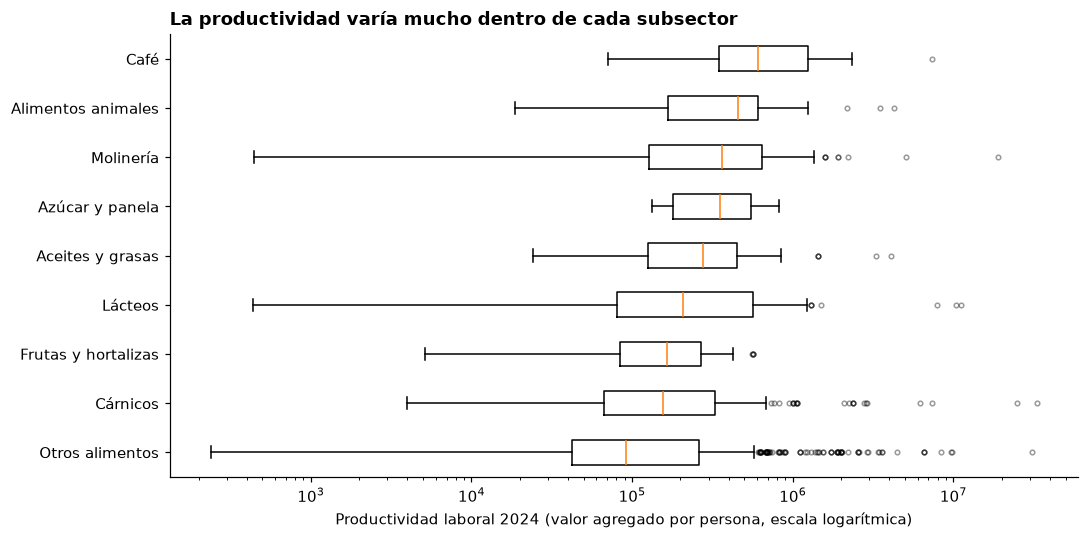

In [2]:
datos = eam[(eam["anio"] == 2024) & (~eam["sin_personal"]) & (eam["productividad_laboral"] > 0)]
orden = datos.groupby("grupo")["productividad_laboral"].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([datos.loc[datos["grupo"] == g, "productividad_laboral"] for g in orden],
           vert=False, showfliers=True, flierprops={"markersize": 3, "alpha": 0.4})
ax.set_yticks(range(1, len(orden) + 1), orden)
ax.set_xscale("log")
ax.set_xlabel("Productividad laboral 2024 (valor agregado por persona, escala logarítmica)")
ax.set_title("La productividad varía mucho dentro de cada subsector", loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_distribucion_productividad.png", bbox_inches="tight")
plt.show()

Productividad muy desigual. Dentro de un mismo subsector hay establecimientos 100 veces más productivos que otros; por eso se usa escala logarítmica.

Productividad 2021 vs 2024

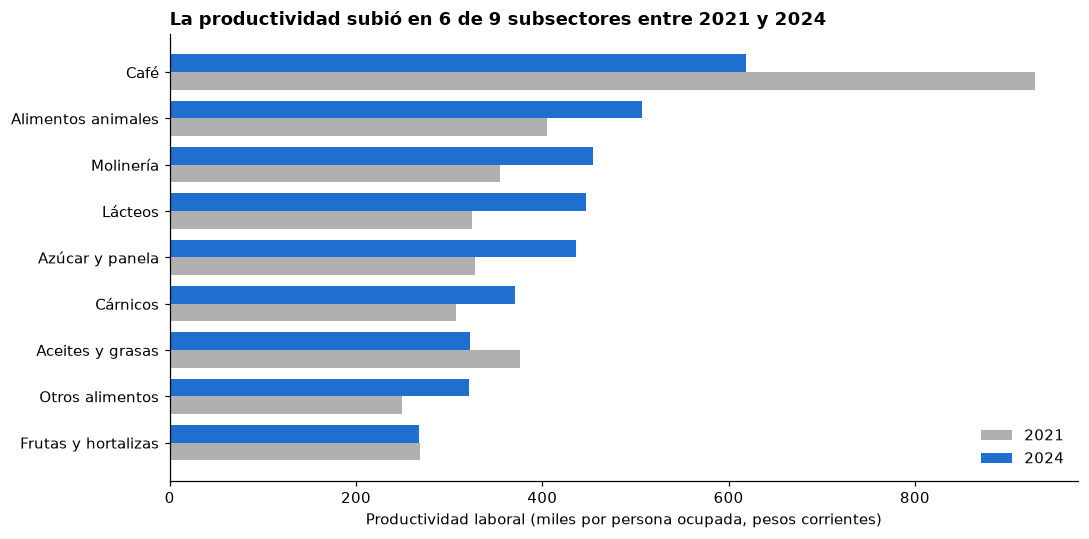

In [3]:
tabla = gold.pivot(index="grupo", columns="anio", values="productividad_laboral").sort_values(2024)

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(tabla))
alto = 0.38
ax.barh(y - alto / 2, tabla[2021] / 1000, height=alto, color=GRIS, label="2021")
ax.barh(y + alto / 2, tabla[2024] / 1000, height=alto, color=AZUL, label="2024")
ax.set_yticks(y, tabla.index)
ax.set_xlabel("Productividad laboral (miles por persona ocupada, pesos corrientes)")
ax.set_title("La productividad subió en 6 de 9 subsectores entre 2021 y 2024", loc="left", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_productividad_2021_2024.png", bbox_inches="tight")
plt.show()

Tendencia entre años. La productividad subió en 6 de 9 subsectores. Café, aceites y frutas bajaron.

Ranking de índice de Digitalización

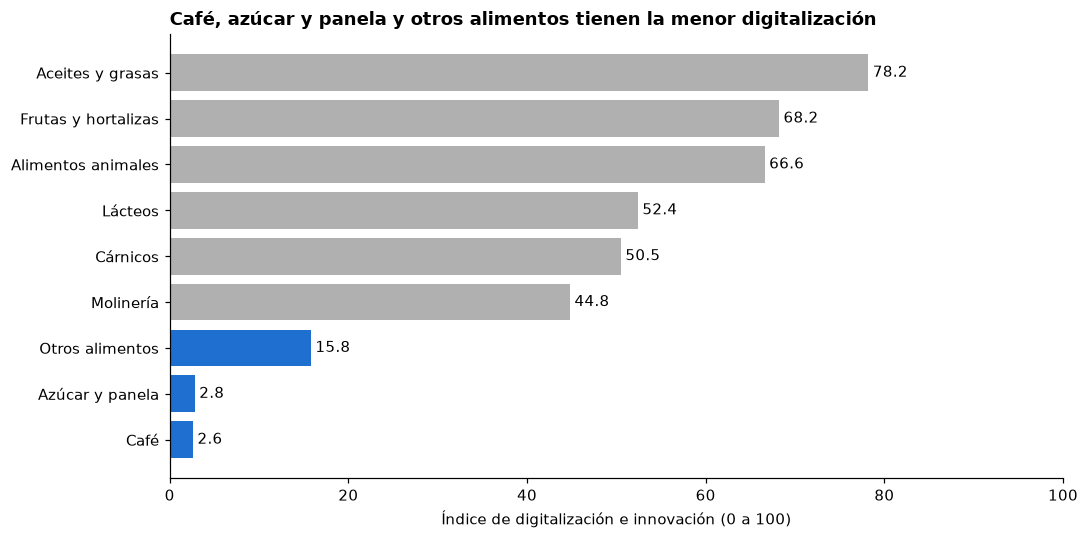

In [4]:
base = gold[gold["anio"] == 2024].sort_values("indice_digitalizacion")
colores = [AZUL if v < 20 else GRIS for v in base["indice_digitalizacion"]]

fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.barh(base["grupo"], base["indice_digitalizacion"], color=colores)
ax.bar_label(barras, fmt="%.1f", padding=3)
ax.set_xlim(0, 100)
ax.set_xlabel("Índice de digitalización e innovación (0 a 100)")
ax.set_title("Café, azúcar y panela y otros alimentos tienen la menor digitalización", loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_indice_digitalizacion.png", bbox_inches="tight")
plt.show()

Mayor rezago. Café, azúcar y panela y otros alimentos tienen la menor digitalización.

índice vs productividad

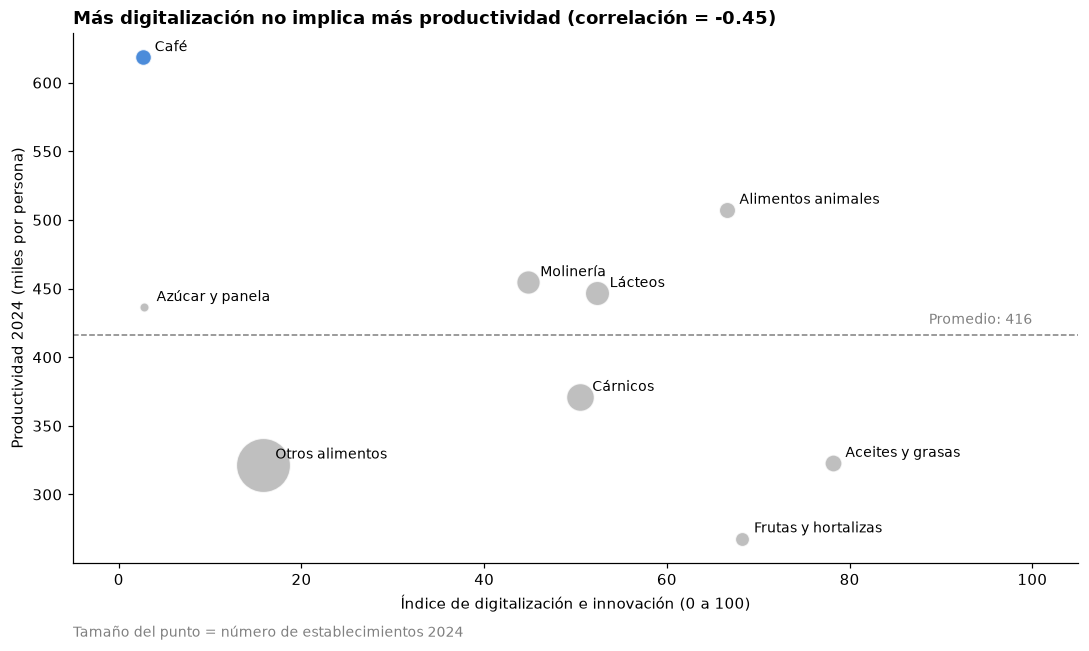

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
for _, r in base.iterrows():
    color = AZUL if r["ciiu3"] == 106 else GRIS
    ax.scatter(r["indice_digitalizacion"], r["productividad_laboral"] / 1000,
               s=r["n_establecimientos"] * 2, color=color, alpha=0.8, edgecolor="white")
    ax.annotate(r["grupo"], (r["indice_digitalizacion"], r["productividad_laboral"] / 1000),
                xytext=(8, 4), textcoords="offset points", fontsize=9)

media = base["productividad_laboral"].mean() / 1000
ax.axhline(media, color="gray", linestyle="--", linewidth=1)
ax.text(100, media + 8, f"Promedio: {media:,.0f}", ha="right", fontsize=9, color="gray")

corr = base["indice_digitalizacion"].corr(base["productividad_laboral"])
ax.set_xlim(-5, 105)
ax.set_xlabel("Índice de digitalización e innovación (0 a 100)")
ax.set_ylabel("Productividad 2024 (miles por persona)")
ax.set_title(f"Más digitalización no implica más productividad (correlación = {corr:.2f})",
             loc="left", fontweight="bold")
ax.text(0, -0.14, "Tamaño del punto = número de establecimientos 2024",
        transform=ax.transAxes, fontsize=9, color="gray")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_indice_vs_productividad.png", bbox_inches="tight")
plt.show()

La paradoja. La correlación entre índice y productividad es −0,45: más digitalización no implica más productividad.


Mapa de calor de correlaciones 

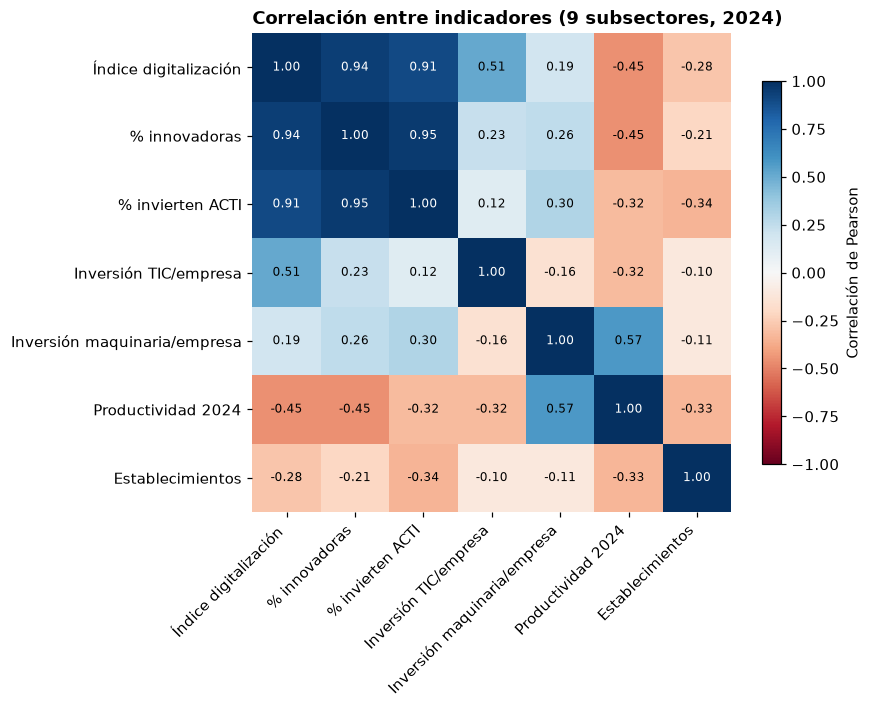

In [6]:
indicadores = {"indice_digitalizacion": "Índice digitalización",
               "pct_empresas_innovadoras": "% innovadoras",
               "pct_empresas_invierten_acti": "% invierten ACTI",
               "inversion_tic_por_empresa": "Inversión TIC/empresa",
               "inversion_maquinaria_por_empresa": "Inversión maquinaria/empresa",
               "productividad_laboral": "Productividad 2024",
               "n_establecimientos": "Establecimientos"}
matriz = base[list(indicadores)].rename(columns=indicadores).corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(matriz, cmap="RdBu", vmin=-1, vmax=1)
ax.set_xticks(range(len(matriz)), matriz.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matriz)), matriz.index)
for i in range(len(matriz)):
    for j in range(len(matriz)):
        v = matriz.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlación de Pearson")
ax.set_title("Correlación entre indicadores (9 subsectores, 2024)", loc="left", fontweight="bold")
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_correlaciones.png", bbox_inches="tight")
plt.show()

Hallazgo nuevo del mapa de calor. La inversión en maquinaria sí se relaciona positivamente con la productividad (+0,57), a diferencia de la inversión en TIC. Para estos subsectores, la automatización física parece pesar más que la digital. Es un insight valioso para tu storytelling.

Concentración por departamento

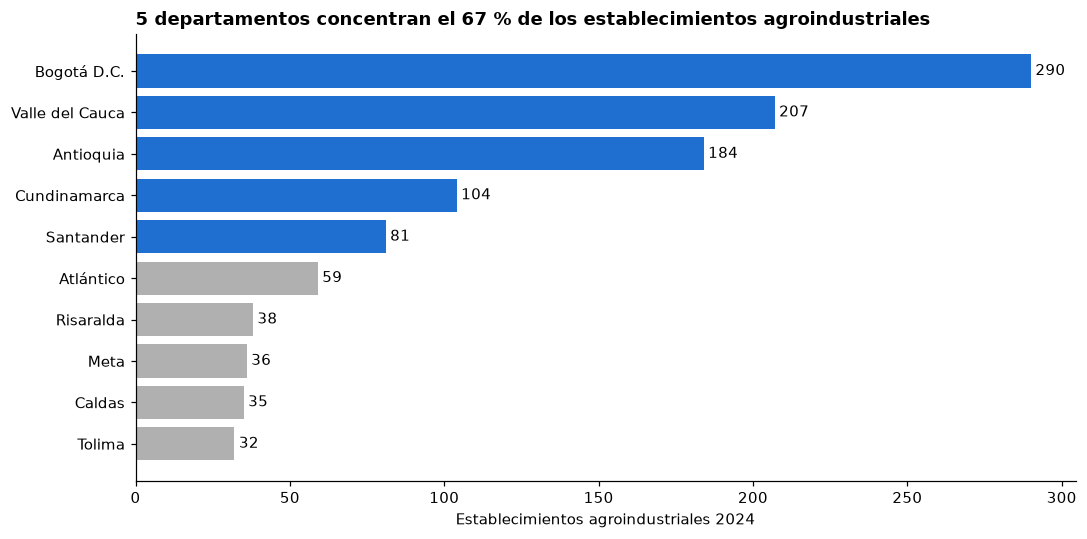

In [7]:
departamentos = {5: "Antioquia", 8: "Atlántico", 11: "Bogotá D.C.", 13: "Bolívar", 15: "Boyacá",
                 17: "Caldas", 18: "Caquetá", 19: "Cauca", 20: "Cesar", 23: "Córdoba",
                 25: "Cundinamarca", 27: "Chocó", 41: "Huila", 44: "La Guajira", 47: "Magdalena",
                 50: "Meta", 52: "Nariño", 54: "Norte de Santander", 63: "Quindío", 66: "Risaralda",
                 68: "Santander", 70: "Sucre", 73: "Tolima", 76: "Valle del Cauca", 81: "Arauca",
                 85: "Casanare", 86: "Putumayo", 88: "San Andrés", 91: "Amazonas", 94: "Guainía",
                 95: "Guaviare", 97: "Vaupés", 99: "Vichada"}
eam["departamento"] = eam["cod_departamento"].map(departamentos)

dpto = eam[eam["anio"] == 2024]["departamento"].value_counts()
top = dpto.head(10).sort_values()
pct_top5 = dpto.head(5).sum() / dpto.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.barh(top.index, top.values,
                 color=[AZUL if d in dpto.head(5).index else GRIS for d in top.index])
ax.bar_label(barras, padding=3)
ax.set_xlabel("Establecimientos agroindustriales 2024")
ax.set_title(f"5 departamentos concentran el {pct_top5:.0f} % de los establecimientos agroindustriales",
             loc="left", fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_departamentos.png", bbox_inches="tight")
plt.show()

Concentración territorial. Bogotá, Valle, Antioquia, Cundinamarca y Santander tienen el 67 % de los establecimientos.
